In [14]:
import json
import re
from pprint import pprint
from pathlib import Path
from collections import Counter
from statistics import mean, median
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = Path("..").resolve()

# IDs de ejemplo usados a lo largo del notebook
ID_PATTERN  = "2605.12474"  # pattern_based: Abstract header detectado
ID_FALLBACK = "2604.26981"  # fallback: formato IEEE, 'Abstract—' sin salto de línea
ID_WORST    = "2605.01582"  # fallback: score bajo, resultado muy diferente al API

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /home/diego/arxiv_classifier


## Sección 1 — El problema con los PDFs

### 1.1 Por qué los PDFs son difíciles de procesar

Un PDF no es un documento de texto. Es un conjunto de instrucciones de renderizado que le dicen a una impresora (o a una pantalla) *dónde* dibujar cada carácter, cada línea y cada imagen. No hay una representación semántica de "párrafo", "título" o "abstract".

Esto genera cinco tipos de dificultades concretas al extraer texto:

| Problema | Descripción | Frecuencia en arXiv |
|----------|-------------|---------------------|
| **Texto nativo vs. escaneado** | Los PDFs escaneados son imágenes, no texto — requieren OCR | Baja (~5 %) |
| **Columnas múltiples** | El texto fluye en 2 columnas; si se lee de izquierda a derecha, mezcla las dos | Alta — muchos papers de CS usan formato de 2 columnas |
| **Fórmulas matemáticas** | Las ecuaciones son imágenes o encoding especial, no texto Unicode | Alta — cualquier paper teórico |
| **Figuras con texto** | Texto en diagramas, gráficos y tablas no es legible como texto | Media |
| **Headers y footers** | Números de página, título del paper, nombre de la conferencia se insertan entre el contenido | Alta — especialmente en papers con plantilla de conferencia |

El abstract de un paper de arXiv es generalmente texto nativo (no escaneado) y aparece en la primera página. Pero su **posición exacta, su formato y los separadores que lo delimitan varían según la plantilla usada** (arXiv genérica, IEEE, ACM, NeurIPS, etc.).

Esta variación es el problema central que abordan las heurísticas de la Sección 2.

In [15]:
# Abrir un PDF con PyMuPDF y mostrar su metadata embebida
import fitz  # PyMuPDF

pdf_path = ROOT / f"data/pdfs/cs.AI/{ID_PATTERN}.pdf"
doc = fitz.open(pdf_path)

print(f"Archivo:      {pdf_path.name}")
print(f"Páginas:      {len(doc)}")
print(f"Formato:      {doc.metadata.get('format', '-')}")
print(f"Título:       {doc.metadata.get('title', '(no embebido)')}")
print(f"Autor:        {doc.metadata.get('author', '(no embebido)')}")
print(f"Creador:      {doc.metadata.get('creator', '-')}")
print(f"Productor:    {doc.metadata.get('producer', '-')}")
print()
print("Nota: los metadatos embebidos en el PDF rara vez son fiables en arXiv.")
print("La mayoría de papers no tienen título ni autor embebidos.")
doc.close()

Archivo:      2605.12474.pdf
Páginas:      28
Formato:      PDF 1.7
Título:       Reward Hacking in Rubric-Based Reinforcement Learning
Autor:        Anas Mahmoud; MohammadHossein Rezaei; Zihao Wang; Anisha Gunjal; Bing Liu; Yunzhong He
Creador:      arXiv GenPDF (tex2pdf:a6404ea)
Productor:    pikepdf 8.15.1

Nota: los metadatos embebidos en el PDF rara vez son fiables en arXiv.
La mayoría de papers no tienen título ni autor embebidos.


In [18]:
pdf_path

PosixPath('/home/diego/arxiv_classifier/data/pdfs/cs.AI/2605.12474.pdf')

In [19]:
# Extraer el texto crudo de la página 1 del mismo paper
# El estudiante ve directamente el ruido antes de cualquier procesamiento
doc = fitz.open(pdf_path)
raw_page1 = doc[0].get_text()
doc.close()

print("=" * 70)
print(f"TEXTO CRUDO — PÁGINA 1 de {ID_PATTERN}.pdf")
print("=" * 70)
print(raw_page1[:1800])
print("...")
print()
print(f"Total de caracteres en página 1: {len(raw_page1)}")

TEXTO CRUDO — PÁGINA 1 de 2605.12474.pdf
Reward Hacking in Rubric-Based
Reinforcement Learning
Anas Mahmoud, MohammadHossein Rezaei, Zihao Wang, Anisha Gunjal, Bing Liu,
Yunzhong He
Scale AI
# anas.mahmoud@scale.com
Abstract
Reinforcement learning with verifiable rewards has enabled strong post-training gains in domains such as math
and coding, though many open-ended settings rely on rubric-based rewards. We study reward hacking in rubric-
based RL, where a policy is optimized against a training verifier but evaluated against a cross-family panel of
three frontier judges, reducing dependence on any single evaluator. Our framework separates two sources of
divergence: verifier failure, where the training verifier credits rubric criteria that reference verifiers reject, and
rubric-design limitations, where even strong rubric-based verifiers favor responses that rubric-free judges rate worse
overall. Across medical and science domains, weak verifiers produce large proxy-reward gains that d

> **Punto clave para recordar:** el texto que PyMuPDF extrae de la página 1 mezcla título, autores, afiliaciones, email, resumen y referencias bibliográficas — todo como una sola cadena de texto sin separaciones semánticas. Las heurísticas de la sección siguiente deben encontrar el abstract dentro de este ruido.

## Sección 2 — Heurísticas para localizar el abstract

### 2.1 Qué es una heurística y por qué se usan aquí

Una **heurística** es una regla práctica que funciona bien en la mayoría de los casos pero no garantiza el resultado correcto. Se usan cuando:
- No existe un estándar formal que cumplan todos los documentos
- El problema tiene solución en el 90 %+ de los casos con una regla simple
- El costo de fallar en el 10 % restante es bajo (podemos marcar esos casos y seguir)

En nuestro caso: queremos el abstract, pero no hay forma garantizada de encontrarlo en un PDF de arXiv. Las plantillas varían: algunas tienen un encabezado `Abstract`, otras tienen `ABSTRACT`, otras tienen `Abstract—` (formato IEEE) y otras no tienen ningún encabezado explícito.

### 2.2 Las 3 estrategias en orden de prioridad

El script `src/extraction/extract_pymupdf.py` implementa estas estrategias en cascada:

**Estrategia 1 — Detectar encabezado `Abstract`:**  
Busca la palabra `Abstract` (o `ABSTRACT`) seguida de un salto de línea, 
luego extrae el texto hasta la próxima sección detectada (`Introduction`, `Keywords`, etc.).

```python
re.search(
    r'(?:^|\n)\s*abstract\s*(?:[:—\-])?\s*\n(.*?)'
    r'(?=\n\s*(?:introduction|keywords|references|[0-9]+\.|conclusion|...))',
    text, re.DOTALL | re.IGNORECASE
)
```

**Estrategia 2 — Delimitar el final del abstract:**  
Forma parte de la misma expresión regular: el lookahead `(?=\n\s*introduction...)` detecta la primera sección posterior al abstract y detiene la captura ahí.

**Estrategia 3 — Fallback (primeros 1 500 caracteres):**  
Si la estrategia 1 no encuentra ningún encabezado `Abstract`, se toman los primeros 1 500 caracteres del texto de las 2 primeras páginas. Funciona cuando el abstract está al comienzo y no hay mucho texto antes de él, pero falla cuando hay páginas de portada, listas largas de autores o texto previo.

In [25]:
# Demo de la Estrategia 1: un paper donde el regex encuentra el encabezado Abstract
raw_txt = Path(f"{ROOT}/data/interim/raw_pymupdf/{ID_PATTERN}.txt").read_text(errors='replace')

print(f"Paper: {ID_PATTERN} (cs.AI)")
print()

# Mostrar la zona donde está el Abstract en el texto raw
idx = raw_txt.find('Abstract')
if idx < 0:
    idx = raw_txt.lower().find('abstract')

print("--- Texto alrededor del encabezado Abstract ---")
print(raw_txt[max(0, idx-80):idx+400])
print()

# Aplicar el mismo regex que usa el script de extracción
match = re.search(
    r'(?:^|\n)\s*abstract\s*(?:[:—\-])?\s*\n(.*?)'
    r'(?=\n\s*(?:introduction|keywords|references|[0-9]+\.|conclusion|related|acknowledgment)|\Z)',
    raw_txt, re.DOTALL | re.IGNORECASE
)

if match:
    print("Regex encontró match — Estrategia 1 exitosa")
    print(f"Abstract extraído (primeras 300 chars):")
    print(match.group(1).strip()[:300])
else:
    print("Regex no encontró match")

Paper: 2605.12474 (cs.AI)

--- Texto alrededor del encabezado Abstract ---
ao Wang, Anisha Gunjal, Bing Liu,
Yunzhong He
Scale AI
# anas.mahmoud@scale.com
Abstract
Reinforcement learning with verifiable rewards has enabled strong post-training gains in domains such as math
and coding, though many open-ended settings rely on rubric-based rewards. We study reward hacking in rubric-
based RL, where a policy is optimized against a training verifier but evaluated against a cross-family panel of
three frontier judges, reducing dependence on any single eva

Regex encontró match — Estrategia 1 exitosa
Abstract extraído (primeras 300 chars):
Reinforcement learning with verifiable rewards has enabled strong post-training gains in domains such as math
and coding, though many open-ended settings rely on rubric-based rewards. We study reward hacking in rubric-
based RL, where a policy is optimized against a training verifier but evaluated a


In [27]:
# Demo de la Estrategia 3 (fallback): un paper donde el regex falla
# Caso: formato IEEE donde el abstract sigue en la MISMA línea: 'Abstract—Texto...'
# El regex requiere un salto de línea después del encabezado; sin él, no hay match.
raw_ieee = Path(f"{ROOT}/data/interim/raw_pymupdf/{ID_FALLBACK}.txt").read_text(errors='replace')

print(f"Paper: {ID_FALLBACK} (cs.IR) — formato IEEE dos columnas")
print()

# Mostrar el contexto donde está Abstract en el texto
idx = raw_ieee.find('Abstract')
print("--- Contexto del encabezado Abstract (formato IEEE) ---")
print(repr(raw_ieee[max(0, idx-30):idx+80]))
print()
char_after = raw_ieee[idx + len('Abstract')]
print(f"Carácter justo después de 'Abstract': {repr(char_after)} (ord={ord(char_after)})")
print("El regex espera un salto de línea (\\n) después del encabezado.")
print("En formato IEEE, el abstract comienza en la misma línea: Abstract—Texto...")
print()

# Verificar que el regex falla
match = re.search(
    r'(?:^|\n)\s*abstract\s*(?:[:—\-])?\s*\n(.*?)'
    r'(?=\n\s*(?:introduction|keywords|references|[0-9]+\.|conclusion|related|acknowledgment)|\Z)',
    raw_ieee, re.DOTALL | re.IGNORECASE
)
print(f"Regex match: {match}  →  Cae al fallback")
print()

# El fallback toma los primeros 1500 chars — incluye título y autores
pymupdf_data = json.loads((ROOT / 'data/interim/extracted_pymupdf.json').read_text())
r = next(x for x in pymupdf_data if x['arxiv_id'] == ID_FALLBACK)
pprint(f"Abstract extraído (fallback): {r['abstract_pymupdf'][:1500]}")

Paper: 2604.26981 (cs.IR) — formato IEEE dos columnas

--- Contexto del encabezado Abstract (formato IEEE) ---
'-Fuqaha∗, Senior Member, IEEE\nAbstract—Large Language Models (LLMs) have revolutionized\nthe field of natural l'

Carácter justo después de 'Abstract': '—' (ord=8212)
El regex espera un salto de línea (\n) después del encabezado.
En formato IEEE, el abstract comienza en la misma línea: Abstract—Texto...

Regex match: None  →  Cae al fallback

('Abstract extraído (fallback): 1 Budget-Constrained Online '
 'Retrieval-Augmented Generation: The Chunk-as-a-Service Model Shawqi '
 'Al-Maliki, Ammar Gharaibeh, Mohamed Rahouti, Member, IEEE, Mohammad Ruhul '
 'Amin, Mohamed Abdallah, Senior Member, IEEE, Junaid Qadir, Senior Member, '
 'IEEE, Ala Al-Fuqaha∗, Senior Member, IEEE Abstract—Large Language Models '
 '(LLMs) have revolutionized the field of natural language processing. '
 'However, they exhibit some limitations, including a lack of reliability and '
 'transparency: they m

In [28]:
# Caso donde las heurísticas dan un resultado claramente incorrecto
# El fallback incluye título y lista de autores en lugar del abstract real
metadata = json.loads((ROOT / 'data/raw/metadata.json').read_text(encoding='utf-8'))
meta_by_id = {m['arxiv_id']: m for m in metadata}
pymupdf_data = json.loads((ROOT / 'data/interim/extracted_pymupdf.json').read_text())

r = next(x for x in pymupdf_data if x['arxiv_id'] == ID_WORST)
api_abs = meta_by_id[ID_WORST]['abstract_api']

print(f"Paper: {ID_WORST} ({r['category']}) — método: {r['extraction_method']}")
print()
print("--- Abstract según la API de arXiv (la referencia correcta) ---")
pprint(api_abs[:400])
print()
print("--- Abstract extraído por PyMuPDF (fallback: primeros 1500 chars) ---")
pprint(r['abstract_pymupdf'][:400])
print()
print("PROBLEMA: el fallback captura título + autores + afiliaciones")
print("antes de que empiece el abstract real, que aparece mucho más adelante en el PDF.")

Paper: 2605.01582 (cs.IR) — método: fallback

--- Abstract según la API de arXiv (la referencia correcta) ---
('Authoritative competency frameworks such as ESCO, ROME, and O*NET are '
 'essential for aligning education with labor market needs, yet their '
 'technical complexity and structural heterogeneity hinder practical adoption '
 'by educators. This paper introduces SkillGraph-Service, an interoperable '
 'microservice designed to bridge this gap by unifying these resources into a '
 'provenance-preserving Knowledge Graph')

--- Abstract extraído por PyMuPDF (fallback: primeros 1500 chars) ---
('KG-First, LLM-Fallback: A Hybrid Microservice for Grounded Skill Search and '
 'Explanation Ngoc Luyen Le§‡ ngoc-luyen.le@hds.utc.fr Marie-H´el`ene Abel‡ '
 'marie-helene.abel@hds.utc.fr Bertrand Laforge∗ laforge@lpnhe.in2p3.fr § '
 'Gamaizer.ia, 93340 Le Raincy, France ‡ Universit´e de technologie de '
 'Compi`egne, CNRS, Heudiasyc (Heuristics and Diagnosis of Complex Systems), '
 'CS 603

### 2.3 Conclusión sobre las heurísticas

| Estrategia | Tasa de éxito en el dataset | Cuándo falla |
|------------|----------------------------|----|
| Pattern-based (regex) | 71 % (1 424 / 2 000) | Formato IEEE (`Abstract—`), sin header, abstract en página 2 |
| Fallback (primeros 1 500 chars) | 29 % de los papers | Portadas, listas largas de autores, texto previo largo |

El 71 % de éxito de la estrategia 1 es suficientemente bueno para un pipeline de extracción masiva: los 576 casos de fallback producen un abstract ruidoso pero no vacío. El modelo de clasificación que usamos (embeddings semánticos) es robusto a cierto nivel de ruido — como veremos en los notebooks de entrenamiento.

Una mejora posible sería extender la regex para cubrir `Abstract—` (sin salto de línea). No se implementó porque el abstract de la API ya es suficientemente bueno para entrenamiento, y los PDFs se usan solo como segunda fuente de información.

> **Punto clave para recordar:** las heurísticas para extraer el abstract funcionan bien en el 71 % de los casos con una sola regex. El 29 % restante usa un fallback que es ruidoso pero no vacío. Este nivel de calidad es suficiente para embeddings semánticos, pero predecible en sus fallos: papers con formato IEEE, ACM dos columnas, o listas largas de autores son los más afectados.

## Sección 3 — PyMuPDF vs Docling

### 3.1 Qué hace Docling diferente

**PyMuPDF** extrae texto plano: convierte el PDF a una cadena de caracteres preservando el orden de renderizado (que puede no ser el orden lógico de lectura). Es rápido (~25 ms/paper) pero no entiende la *estructura* del documento.

**Docling** es una librería de IBM Research que convierte el PDF a **Markdown estructurado**. Usa modelos de visión por computadora (layout detection, table recognition) para:
- Separar el contenido en columnas correctamente
- Marcar encabezados como `# Título` y `## Abstract`
- Representar tablas como tablas Markdown
- Indicar imágenes como `<!-- image -->`

El precio: Docling tarda ~22 segundos por paper (≈914× más lento que PyMuPDF). Para 2 000 papers esto serían ~12 horas de procesamiento.

La estrategia de extracción de Docling es más robusta: en lugar de buscar texto `Abstract`, busca el **encabezado Markdown `## Abstract`** que Docling genera al detectar ese bloque de layout.

In [29]:
# Comparar el mismo paper procesado por ambas librerías
paper_id = ID_PATTERN  # 2605.12474 — patrón exitoso en ambas

raw_txt = Path(f"{ROOT}/data/interim/raw_pymupdf/{paper_id}.txt").read_text(errors='replace')
raw_md  = Path(f"{ROOT}/data/interim/raw_docling/{paper_id}.md").read_text(errors='replace')

print("=" * 35, "PYMUPDF (texto plano)", "=" * 35)
print(raw_txt[:800])
print()
print("=" * 35, "DOCLING (markdown)", "=" * 35)
print(raw_md[:900])

=================================== PYMUPDF (texto plano) ===================================
Reward Hacking in Rubric-Based
Reinforcement Learning
Anas Mahmoud, MohammadHossein Rezaei, Zihao Wang, Anisha Gunjal, Bing Liu,
Yunzhong He
Scale AI
# anas.mahmoud@scale.com
Abstract
Reinforcement learning with verifiable rewards has enabled strong post-training gains in domains such as math
and coding, though many open-ended settings rely on rubric-based rewards. We study reward hacking in rubric-
based RL, where a policy is optimized against a training verifier but evaluated against a cross-family panel of
three frontier judges, reducing dependence on any single evaluator. Our framework separates two sources of
divergence: verifier failure, where the training verifier credits rubric criteria that reference verifiers reject, and
rubric-design limitations, where even strong rubric-based v

=================================== DOCLING (markdown) ===================================
<!-- image --

In [30]:
# Comparar el abstract extraído por cada librería vs el abstract oficial de la API
pymupdf_data = json.loads((ROOT / 'data/interim/extracted_pymupdf.json').read_text())
docling_data = json.loads((ROOT / 'data/interim/extracted_docling.json').read_text())
metadata     = json.loads((ROOT / 'data/raw/metadata.json').read_text(encoding='utf-8'))
meta_by_id   = {m['arxiv_id']: m for m in metadata}

r_pym = next(x for x in pymupdf_data if x['arxiv_id'] == paper_id)
r_doc = next(x for x in docling_data if x['arxiv_id'] == paper_id)
api   = meta_by_id[paper_id]['abstract_api']

print(f"Paper: {paper_id}")
print(f"PyMuPDF — método: {r_pym['extraction_method']}")
print(f"Docling  — método: {r_doc['extraction_method']}")
print()
print("--- API (referencia) ---")
print(api[:350])
print()
print("--- PyMuPDF ---")
print(r_pym['abstract_pymupdf'][:350])
print()
print("--- Docling ---")
print(r_doc['abstract_docling'][:350])

Paper: 2605.12474
PyMuPDF — método: pattern_based
Docling  — método: markdown_structure

--- API (referencia) ---
Reinforcement learning with verifiable rewards has enabled strong post-training gains in domains such as math and coding, though many open-ended settings rely on rubric-based rewards. We study reward hacking in rubric-based RL, where a policy is optimized against a training verifier but evaluated against a cross-family panel of three frontier judge

--- PyMuPDF ---
Reinforcement learning with verifiable rewards has enabled strong post-training gains in domains such as math and coding, though many open-ended settings rely on rubric-based rewards. We study reward hacking in rubricbased RL, where a policy is optimized against a training verifier but evaluated against a cross-family panel of three frontier judges

--- Docling ---
Reinforcement learning with verifiable rewards has enabled strong post-training gains in domains such as math and coding, though many open-ended setti

In [31]:
# Tiempos de procesamiento: comparativa desde los registros individuales
pym_times = sorted(r['timing']['total_seg'] for r in pymupdf_data if 'timing' in r)
doc_times = sorted(r['timing']['total_seg'] for r in docling_data if 'timing' in r)

def pct(lst, p):
    return lst[int(p * len(lst))]

def show_stats(name, times):
    n = len(times)
    print(f"{name}:")
    print(f"  N papers procesados:  {n:>6}")
    print(f"  Tiempo promedio:      {sum(times)/n:>9.3f} s")
    print(f"  Tiempo mediano:       {pct(times, 0.5):>9.3f} s")
    print(f"  Percentil 95:         {pct(times, 0.95):>9.3f} s")
    print(f"  Tiempo total acum.:   {sum(times):>9.1f} s")
    print(f"  Extrapolado a 2000:   {2000 * sum(times)/n / 60:>9.1f} min")
    print()

show_stats("PyMuPDF", pym_times)
show_stats("Docling", doc_times)

speedup = (sum(doc_times)/len(doc_times)) / (sum(pym_times)/len(pym_times))
print(f"PyMuPDF es {speedup:.0f}× más rápido que Docling en promedio")

PyMuPDF:
  N papers procesados:    2000
  Tiempo promedio:          0.024 s
  Tiempo mediano:           0.021 s
  Percentil 95:             0.040 s
  Tiempo total acum.:        47.4 s
  Extrapolado a 2000:         0.8 min

Docling:
  N papers procesados:    2000
  Tiempo promedio:         16.060 s
  Tiempo mediano:          12.250 s
  Percentil 95:            41.439 s
  Tiempo total acum.:     32120.2 s
  Extrapolado a 2000:       535.3 min

PyMuPDF es 677× más rápido que Docling en promedio


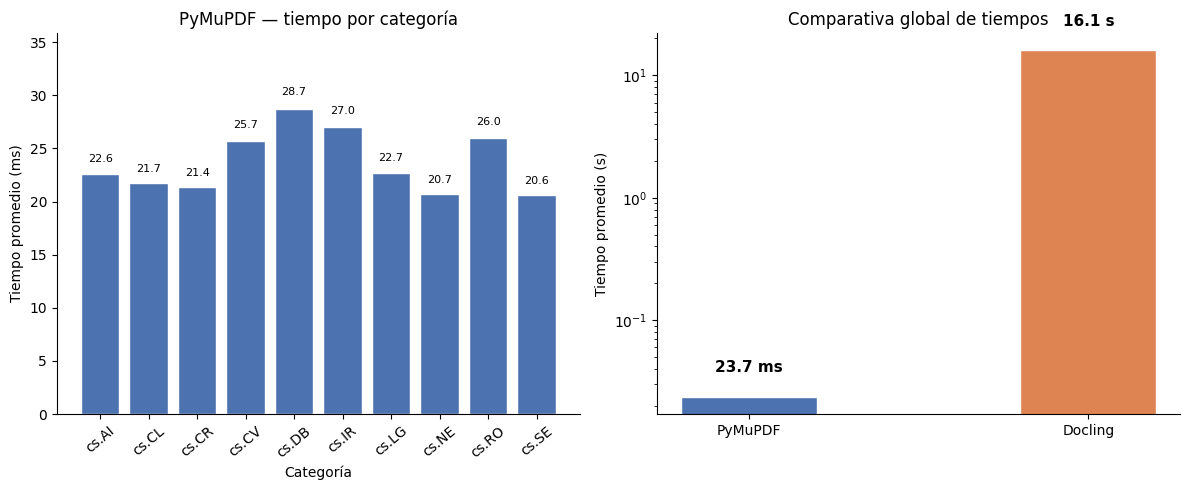

In [32]:
# Gráfico: tiempos promedio por categoría — PyMuPDF
# (Docling solo tiene cs.AI y cs.CL, se muestra como referencia)
timing_pym = json.loads((ROOT / 'reports/timing_pymupdf.json').read_text())

cats = sorted(timing_pym['por_categoria'].keys())
pym_avg = [timing_pym['por_categoria'][c]['promedio_seg'] for c in cats]

# Tiempo promedio Docling desde registros individuales
doc_by_cat = {}
for r in docling_data:
    doc_by_cat.setdefault(r['category'], []).append(r['timing']['total_seg'])
doc_global_avg = sum(doc_times) / len(doc_times)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PyMuPDF por categoría
ax = axes[0]
bars = ax.bar(cats, [t * 1000 for t in pym_avg], color='#4C72B0', edgecolor='white')
ax.set_xlabel('Categoría')
ax.set_ylabel('Tiempo promedio (ms)')
ax.set_title('PyMuPDF — tiempo por categoría')
ax.set_ylim(0, max(t * 1000 for t in pym_avg) * 1.25)
for bar, val in zip(bars, pym_avg):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.04,
            f'{val*1000:.1f}', ha='center', va='bottom', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
for lbl in ax.get_xticklabels(): lbl.set_rotation(40)

# Comparativa global PyMuPDF vs Docling
ax2 = axes[1]
librerias = ['PyMuPDF', 'Docling']
tiempos   = [sum(pym_times)/len(pym_times), doc_global_avg]
colores   = ['#4C72B0', '#DD8452']
bars2 = ax2.bar(librerias, tiempos, color=colores, edgecolor='white', width=0.4)
ax2.set_ylabel('Tiempo promedio (s)')
ax2.set_title('Comparativa global de tiempos')
ax2.set_yscale('log')  # escala log por la diferencia de magnitud
for bar, val in zip(bars2, tiempos):
    label = f'{val*1000:.1f} ms' if val < 1 else f'{val:.1f} s'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.5,
             label, ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 La pregunta del trade-off

| | PyMuPDF | Docling |
|-|---------|---------|
| **Velocidad** | ~24 ms / paper | ~22 s / paper |
| **Para 2 000 papers** | ~47 segundos | ~12 horas |
| **Calidad de extracción** | Depende del formato del paper | Mejor en papers con layouts complejos |
| **Método de detección** | Regex sobre texto plano | Markdown heading detectado por modelo de layout |
| **Tasa de pattern-based** | 71 % (1424/2000) | 82 % (170/207 en cs.AI) |

**¿Vale la diferencia de calidad el costo de tiempo?**

Para este proyecto: **no**. Usamos los abstracts del PDF solo como segunda fuente de información (la primera y principal es el abstract de la API, que ya está disponible sin necesidad de descargar el PDF). La mejora de calidad de Docling en los casos difíciles no justifica un procesamiento 914× más lento.

En un proyecto diferente — por ejemplo, extraer el texto completo del paper para clasificación de secciones o para RAG — Docling sería la opción preferida.

> **Punto clave para recordar:** PyMuPDF y Docling producen calidad similar en abstracts de papers estándar. La diferencia de velocidad (914×) hace que PyMuPDF sea la elección obvia para procesamiento masivo. Docling vale la pena cuando la estructura del documento importa (secciones, tablas, layouts complejos).

## Sección 4 — Análisis de fallos

In [34]:
# Tasa de éxito de cada heurística por librería y por categoría
pymupdf_data = json.loads((ROOT / 'data/interim/extracted_pymupdf.json').read_text())
docling_data = json.loads((ROOT / 'data/interim/extracted_docling.json').read_text())

# PyMuPDF: success=2000, desglose por método
pym_by_cat = {}
for r in pymupdf_data:
    cat = r['category']
    pym_by_cat.setdefault(cat, {'pattern_based': 0, 'fallback': 0})
    pym_by_cat[cat][r['extraction_method']] += 1

print("PyMuPDF — tasa de patrón detectado (heurística 1) por categoría:")
print(f"{'Categoría':<12}  {'Pattern-based':>14}  {'Fallback':>9}  {'% Pattern':>10}")
print("-" * 52)
for cat in sorted(pym_by_cat):
    pb = pym_by_cat[cat]['pattern_based']
    fb = pym_by_cat[cat]['fallback']
    total = pb + fb
    print(f"{cat:<12}  {pb:>14}  {fb:>9}  {pb/total*100:>9.1f}%")

total_pb = sum(d['pattern_based'] for d in pym_by_cat.values())
total_fb = sum(d['fallback'] for d in pym_by_cat.values())
print("-" * 52)
print(f"{'TOTAL':<12}  {total_pb:>14}  {total_fb:>9}  {total_pb/2000*100:>9.1f}%")

print()
# Docling: solo cs.AI y cs.CL
doc_by_cat = {}
for r in docling_data:
    cat = r['category']
    doc_by_cat.setdefault(cat, {'markdown_structure': 0, 'fallback': 0})
    key = r['extraction_method'] if r['extraction_method'] in ('markdown_structure', 'fallback') else 'fallback'
    doc_by_cat[cat][key] += 1

print("Docling — tasa de estructura markdown detectada por categoría:")
print(f"{'Categoría':<12}  {'Markdown struct':>16}  {'Fallback':>9}  {'% Struct':>10}")
print("-" * 54)
for cat in sorted(doc_by_cat):
    ms = doc_by_cat[cat]['markdown_structure']
    fb = doc_by_cat[cat]['fallback']
    total = ms + fb
    print(f"{cat:<12}  {ms:>16}  {fb:>9}  {ms/total*100:>9.1f}%")

PyMuPDF — tasa de patrón detectado (heurística 1) por categoría:
Categoría      Pattern-based   Fallback   % Pattern
----------------------------------------------------
cs.AI                    163         37       81.5%
cs.CL                    170         30       85.0%
cs.CR                    132         68       66.0%
cs.CV                    138         62       69.0%
cs.DB                    149         51       74.5%
cs.IR                    164         36       82.0%
cs.LG                    177         23       88.5%
cs.NE                    119         81       59.5%
cs.RO                     75        125       37.5%
cs.SE                    137         63       68.5%
----------------------------------------------------
TOTAL                   1424        576       71.2%

Docling — tasa de estructura markdown detectada por categoría:
Categoría      Markdown struct   Fallback    % Struct
------------------------------------------------------
cs.AI                      164  

In [35]:
# Identificar papers con fallback en AMBAS librerías
# Estos son los casos donde ninguna heurística detectó el encabezado Abstract
doc_by_id = {r['arxiv_id']: r for r in docling_data}
pym_by_id = {r['arxiv_id']: r for r in pymupdf_data}
metadata  = json.loads((ROOT / 'data/raw/metadata.json').read_text(encoding='utf-8'))
meta_by_id = {m['arxiv_id']: m for m in metadata}

# Papers en la intersección PyMuPDF ∩ Docling con fallback en ambas
both_fallback = [
    aid for aid in doc_by_id
    if pym_by_id.get(aid, {}).get('extraction_method') == 'fallback'
    and doc_by_id[aid].get('extraction_method') == 'fallback'
]
print(f"Papers con fallback en AMBAS librerías: {len(both_fallback)}")
print()

# Examinar 3 casos representativos
casos = ['2605.12481', '2605.12376', '2605.12357']
for aid in casos:
    r_pym = pym_by_id[aid]
    r_doc = doc_by_id[aid]
    raw_txt_path = Path(r_pym['raw_path'])
    raw_md_path  = Path(r_doc['raw_path'])
    raw_txt = raw_txt_path.read_text(errors='replace') if raw_txt_path.exists() else ''
    raw_md  = raw_md_path.read_text(errors='replace')  if raw_md_path.exists()  else ''

    print("=" * 70)
    print(f"Paper: {aid} ({r_pym['category']})")
    print(f"Título: {meta_by_id[aid]['title']}")
    print()
    print("Por qué falló — primeros 400 chars del PDF (texto plano):")
    print(raw_txt[:400])
    print()
    print("Por qué falló — primeros 300 chars del markdown Docling:")
    print(raw_md[:300])
    print()

Papers con fallback en AMBAS librerías: 548

Paper: 2605.12481 (cs.AI)
Título: ToolCUA: Towards Optimal GUI-Tool Path Orchestration for Computer Use Agents

Por qué falló — primeros 400 chars del PDF (texto plano):


Por qué falló — primeros 300 chars del markdown Docling:


Paper: 2605.12376 (cs.AI)
Título: ProfiliTable: Profiling-Driven Tabular Data Processing via Agentic Workflows

Por qué falló — primeros 400 chars del PDF (texto plano):


Por qué falló — primeros 300 chars del markdown Docling:


Paper: 2605.12357 (cs.AI)
Título: $δ$-mem: Efficient Online Memory for Large Language Models

Por qué falló — primeros 400 chars del PDF (texto plano):


Por qué falló — primeros 300 chars del markdown Docling:




### 4.1 Diagnóstico de los tres casos

| Paper | Razón del fallo |
|-------|----------------|
| `2605.12481` | El abstract aparece directamente después de los autores, sin encabezado `Abstract`. El texto del resumen empieza en la misma zona que el fallback captura. |
| `2605.12376` | Formato ACM: autores con nombres en mayúsculas (`WEI LIU, Peking University...`), lista muy larga. El texto útil del abstract aparece mucho después de la posición 1500. |
| `2605.12357` | El paper tiene logos e imágenes institucionales al comienzo (detectados como `<!-- image -->`). Docling los marca pero el texto del abstract no tiene encabezado `Abstract` explícito. |

### 4.2 Qué hacer con estos fallos en un pipeline real

Hay tres opciones:

**1. Descartar** — eliminar del dataset los papers donde la extracción falló.  
Ventaja: el dataset restante tiene alta calidad.  
Desventaja: si los fallos no son aleatorios (e.g., afectan más a papers de cs.NE o cs.RO), se introduce sesgo.

**2. Marcar como `bajo_confianza`** — mantener los registros pero añadir un flag.  
Permite entrenar con todos los datos y analizar si los papers bajo_confianza tienen peor accuracy en el modelo. Es la opción más informativa.

**3. OCR adicional o segunda estrategia** — para papers fallidos, aplicar una estrategia más costosa: OCR con Tesseract, o afinar la regex para cubrir `Abstract—` sin salto de línea.  
Vale la pena si el volumen de fallos es grande y la mejora de calidad es medible.

**Decisión en este proyecto:** dado que usamos principalmente `abstract_api` (el abstract oficial de la API) para el entrenamiento, los fallos de extracción del PDF son secundarios. Los 576 casos de fallback se mantienen en el dataset con el abstract ruidoso — el impacto en el modelo es mínimo porque el abstract de la API es la fuente principal.

> **Punto clave para recordar:** los fallos de extracción no son aleatorios — se concentran en templates específicas (ACM, IEEE) y papers con muchos autores o imágenes. Conocer el *patrón* de fallos es tan importante como conocer la tasa: permite decidir si el sesgo introducido es tolerable o requiere corrección.